# Intraday Momentum Strategy for SPY
Replication of Zarattini, Aziz, Barbon (2025) with train/test split and transaction costs.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

from config import END, START, TEST_START, TRAIN_END
from data import clean_minute_bars, load_daily_total_returns, load_minute_bars, make_daily_tables
from metrics import compute_equity_curve, compute_metrics
from paper_strategy import compute_noise_area, compute_vwap, run_backtest

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

## 1. Data

In [2]:
raw = load_minute_bars("SPY", START, END)
bars = clean_minute_bars(raw)
tables = make_daily_tables(bars)
# Benchmark: SPY on all trading days, adjusted for dividends and splits
benchmark_returns = load_daily_total_returns("SPY", START, END)
print(
    len(tables["close"]), "trading days from", tables["close"].index[0].date(), "to", tables["close"].index[-1].date()
)
display(raw.tail())
display(bars.tail())

1687 trading days from 2020-01-02 to 2026-10-01


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2026-10-01 23:55:00+00:00,764.63,764.63,764.63,764.63,455.0,20.0,764.63
2026-10-01 23:56:00+00:00,764.63,764.63,764.63,764.63,127.0,6.0,764.63
2026-10-01 23:57:00+00:00,764.67,764.67,764.67,764.67,475.0,14.0,764.67
2026-10-01 23:58:00+00:00,764.73,764.73,764.73,764.73,546.0,7.0,764.73
2026-10-01 23:59:00+00:00,764.73,764.73,764.73,764.73,88.0,26.0,764.73


,open,high,low,close,volume
2026-10-01 15:56:00-04:00,764.500,764.500,763.93,764.140,702269.0
2026-10-01 15:57:00-04:00,764.135,764.330,764.06,764.200,213099.0
2026-10-01 15:58:00-04:00,764.180,764.245,763.95,764.010,191874.0
2026-10-01 15:59:00-04:00,764.020,764.037,763.72,763.745,490196.0
2026-10-01 16:00:00-04:00,763.750,764.160,763.47,764.030,1407332.0


## 2. Noise Area on single days
Compare with Figures 2 and 4 of the paper. On 31 Jan 2022 the price leaves the Noise Area upwards, on 20 Jan 2022 the trend reverses and the stop is hit.

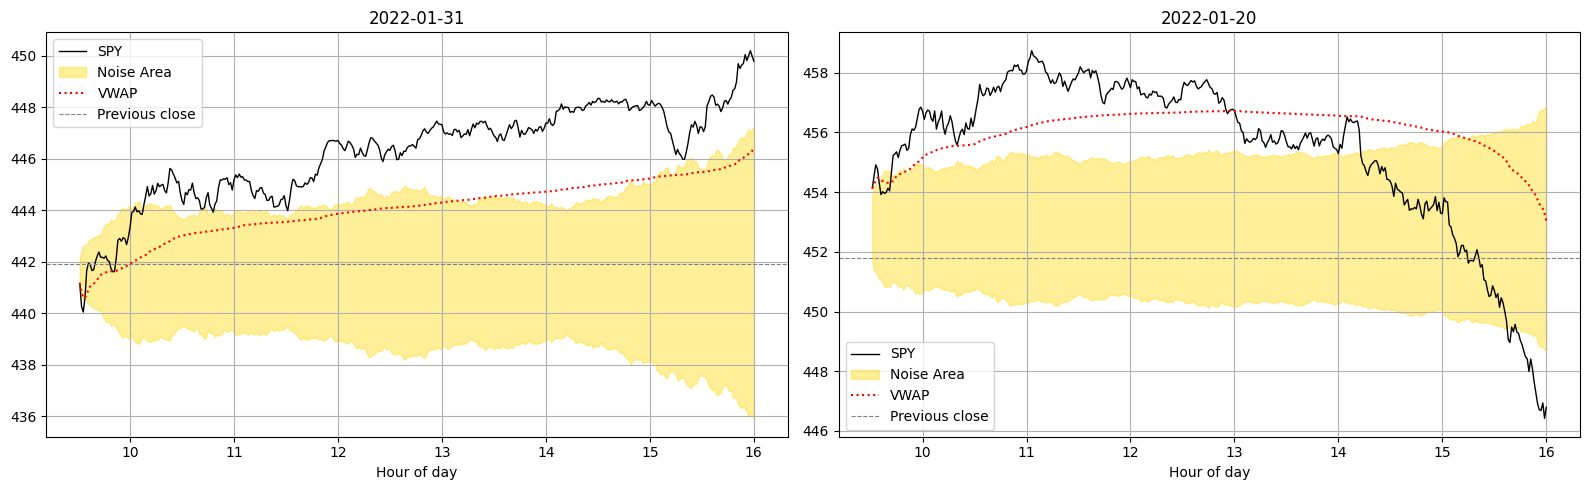

In [3]:
close = tables["close"]
upper, lower = compute_noise_area(close, tables["day_open"], tables["prev_close"])
vwap = compute_vwap(close, tables["volume"])
hours = [t.hour + t.minute / 60 for t in close.columns]


def plot_noise_area(date, ax):
    date = pd.Timestamp(date)
    ax.plot(hours, close.loc[date], color="black", linewidth=1, label="SPY")
    ax.fill_between(hours, lower.loc[date], upper.loc[date], color="gold", alpha=0.4, label="Noise Area")
    ax.plot(hours, vwap.loc[date], color="red", linestyle=":", label="VWAP")
    ax.axhline(tables["prev_close"].loc[date], color="gray", linestyle="--", linewidth=0.8, label="Previous close")
    ax.set_title(date.date())
    ax.set_xlabel("Hour of day")
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_noise_area("2022-01-31", axes[0])
plot_noise_area("2022-01-20", axes[1])
plt.tight_layout()
plt.show()

## 3. Backtest
Three variants from the paper (Tables 2 and 3), identical costs: $0.0035 commission and $0.001 slippage per share. SPY Buy&Hold uses every trading day from the first strategy day on, dividends reinvested.

In [4]:
variants = {
    "Opp.Band, 100%": ("opposite_band", "fixed"),
    "Band+VWAP, 100%": ("band_vwap", "fixed"),
    "Band+VWAP, Dyn.": ("band_vwap", "dynamic"),
}

strategy_returns = {}
for name, (stop_mode, sizing) in variants.items():
    strategy_returns[name], _ = run_backtest(tables, stop_mode, sizing)

spy_returns = benchmark_returns.loc[strategy_returns["Band+VWAP, Dyn."].index[0] :]

## 4. Equity curves
The dashed line separates train (until 2023) and test (from 2024).

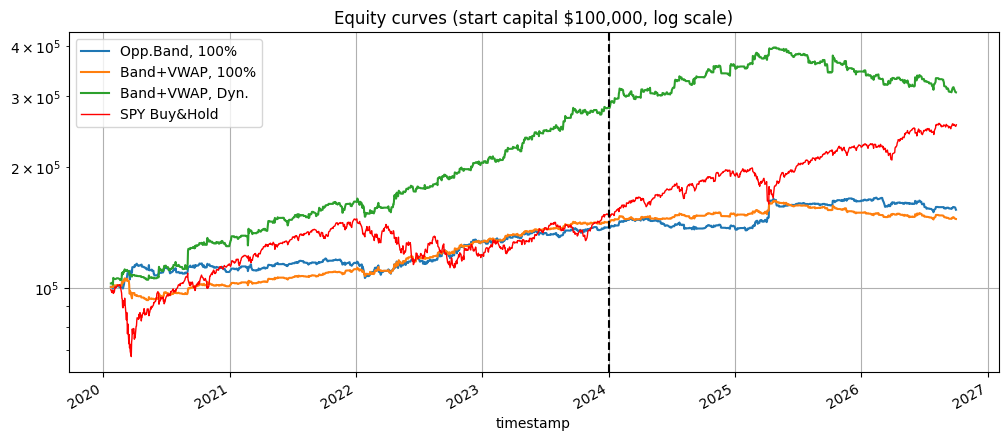

In [5]:
fig, ax = plt.subplots()
for name, returns in strategy_returns.items():
    compute_equity_curve(returns).plot(ax=ax, label=name)
compute_equity_curve(spy_returns).plot(ax=ax, label="SPY Buy&Hold", color="red", linewidth=1)
ax.axvline(pd.Timestamp(TEST_START), color="black", linestyle="--")
ax.set_yscale("log")
ax.set_title("Equity curves (start capital $100,000, log scale)")
ax.legend()
plt.show()

## 5. Performance metrics by period

In [6]:
periods = {"Train": slice(None, TRAIN_END), "Test": slice(TEST_START, None)}

results = {}
for period_name, period in periods.items():
    rows = {}
    for name, returns in strategy_returns.items():
        rows[name] = compute_metrics(returns.loc[period], benchmark_returns)
    rows["SPY Buy&Hold"] = compute_metrics(spy_returns.loc[period])
    results[period_name] = pd.DataFrame(rows).T
    print(period_name)
    display(results[period_name].round(3))

Train


,total_return,annual_return,annual_volatility,sharpe_ratio,hit_ratio,max_drawdown,alpha,beta
"Opp.Band, 100%",0.416,0.093,0.105,0.898,0.603,0.106,0.094,-0.000
"Band+VWAP, 100%",0.458,0.101,0.079,1.265,0.497,0.117,0.100,-0.001
"Band+VWAP, Dyn.",1.812,0.301,0.144,1.901,0.497,0.099,0.281,-0.047
SPY Buy&Hold,0.526,0.113,0.223,0.594,0.536,0.338,NaN,NaN


Test


,total_return,annual_return,annual_volatility,sharpe_ratio,hit_ratio,max_drawdown,alpha,beta
"Opp.Band, 100%",0.107,0.038,0.086,0.477,0.524,0.080,0.025,0.085
"Band+VWAP, 100%",0.019,0.007,0.057,0.148,0.431,0.101,0.007,0.007
"Band+VWAP, Dyn.",0.093,0.033,0.145,0.295,0.431,0.227,0.054,-0.059
SPY Buy&Hold,0.672,0.206,0.155,1.284,0.562,0.188,NaN,NaN


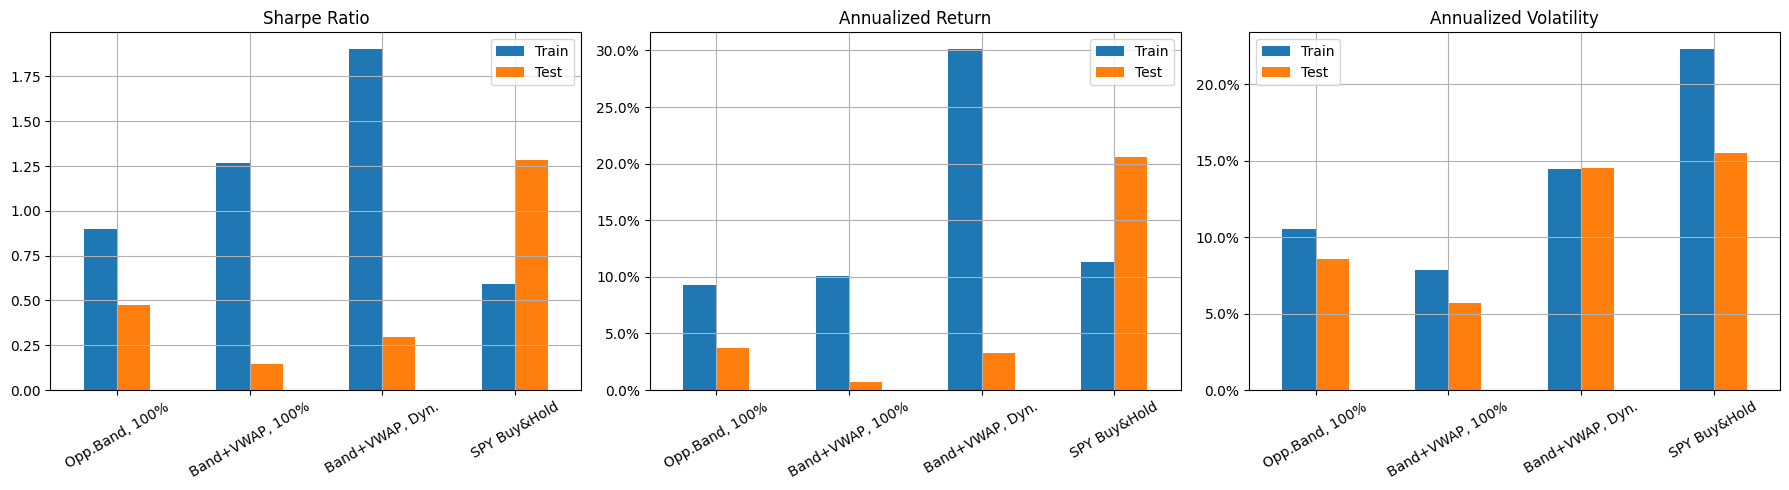

In [7]:
metric_titles = {
    "sharpe_ratio": "Sharpe Ratio",
    "annual_return": "Annualized Return",
    "annual_volatility": "Annualized Volatility",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, title) in zip(axes, metric_titles.items()):
    table = pd.DataFrame({period_name: results[period_name][metric] for period_name in results})
    table.plot.bar(ax=ax, rot=30)
    ax.set_title(title)
    if metric != "sharpe_ratio":
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## 6. Yearly returns
The first and last year are partial (14-day warm-up in 2020, data until the end of the sample in 2026).

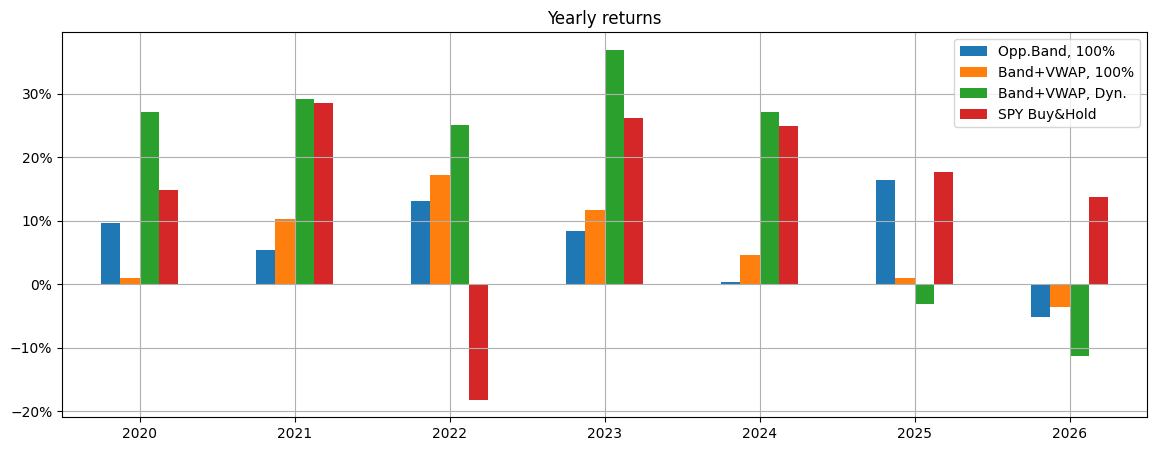

In [8]:
yearly = pd.DataFrame(
    {name: (1 + returns).groupby(returns.index.year).prod() - 1 for name, returns in strategy_returns.items()}
)
yearly["SPY Buy&Hold"] = (1 + spy_returns).groupby(spy_returns.index.year).prod() - 1

ax = yearly.plot.bar(figsize=(14, 5), rot=0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Yearly returns")
plt.show()

## 7. Drawdowns

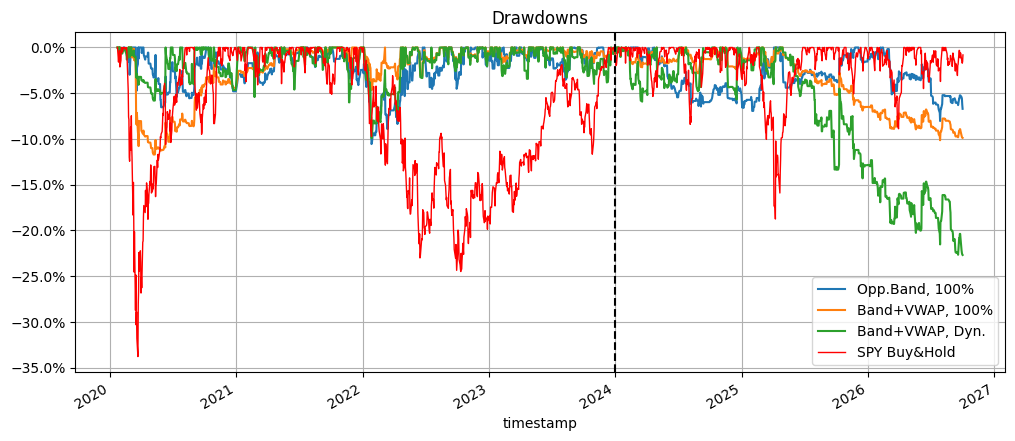

In [9]:
fig, ax = plt.subplots()
for name, returns in strategy_returns.items():
    equity = compute_equity_curve(returns)
    (equity / equity.cummax() - 1).plot(ax=ax, label=name)
spy_equity = compute_equity_curve(spy_returns)
(spy_equity / spy_equity.cummax() - 1).plot(ax=ax, label="SPY Buy&Hold", color="red", linewidth=1)
ax.axvline(pd.Timestamp(TEST_START), color="black", linestyle="--")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Drawdowns")
ax.legend()
plt.show()

## 8. Monthly returns (like FAQ Q24 of the paper)
Same layout as the table in Q24 (compounded monthly returns in %, last column = yearly). Strategy: Band+VWAP with dynamic sizing, the one shown in Q24. The first month of 2020 is partial (14-day warm-up). Below the table: difference to the paper's numbers for the overlapping years 2020-2025 (positive = mine is higher).

In [10]:
from metrics import MONTH_NAMES, compare_with_paper_q24, compute_q24_tables


def show_q24(returns, title):
    """Monthly table in the layout of FAQ Q24 of the paper (values in %) plus train/test summary."""
    table, summary = compute_q24_tables(returns, TEST_START)
    display(
        table.style.format("{:.1f}", na_rep="")
        .background_gradient(cmap="RdYlGn", vmin=-10, vmax=10, subset=MONTH_NAMES)
        .set_caption(title)
    )
    display(summary.round(3))
    return table


q24 = show_q24(strategy_returns["Band+VWAP, Dyn."], "Band+VWAP, dynamic sizing: monthly returns in %")

difference, correlation = compare_with_paper_q24(q24)
display(difference.style.format("{:+.1f}", na_rep="").set_caption("Mine minus paper (Q24), percentage points"))
print(f"Correlation of monthly returns with the paper (2020-2025): {correlation:.2f}")

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Yearly
Year,,,,,,,,,,,,,
2020,6.0,2.2,-0.5,-1.9,0.0,7.5,-0.1,-1.8,14.6,2.9,-1.1,-2.2,27.1
2021,5.3,2.4,0.9,5.9,2.1,-1.1,2.7,1.5,2.6,3.2,-3.3,3.9,29.2
2022,-6.4,2.9,0.2,9.0,2.1,0.8,0.1,6.2,-0.9,5.9,1.3,2.3,25.1
2023,2.8,-1.3,7.8,2.2,4.1,3.4,1.4,6.0,3.5,-1.3,0.5,3.1,36.9
2024,8.6,-1.3,-0.8,5.5,-4.4,1.5,8.1,-2.9,4.3,6.5,-4.0,4.2,27.1
2025,-1.4,7.7,-0.2,4.4,-2.1,-1.2,-2.0,-2.9,-5.4,5.7,-3.1,-1.8,-3.1
2026,-3.9,-0.4,0.6,-1.0,-3.3,3.9,-3.0,-1.3,-3.2,-0.1,,,-11.3


,annual_return,annual_volatility,sharpe_ratio,max_drawdown
Train,0.301,0.144,1.901,0.099
Test,0.033,0.145,0.295,0.227
Full,0.183,0.145,1.239,0.227


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Yearly
Year,,,,,,,,,,,,,
2020,+0.7,+0.3,-0.0,-0.1,+0.2,-0.5,-0.2,-0.0,+0.3,+0.1,-0.0,-0.3,+0.3
2021,-2.5,-0.7,+0.2,-0.2,-0.5,-0.1,-0.1,-0.2,-0.2,-0.1,-0.1,-0.2,-5.6
2022,-0.9,+0.1,+0.0,-0.0,-0.0,+0.3,-0.1,-0.1,+0.1,+0.1,-0.3,+1.6,+0.7
2023,-0.1,+0.0,+0.0,+0.4,+1.2,-0.7,-0.8,+0.0,+0.6,-0.2,+0.0,-0.7,-0.3
2024,-0.2,+0.2,-0.4,-0.3,-0.1,-0.1,-0.1,-0.1,+0.2,-0.2,-1.4,-1.5,-5.1
2025,-0.2,,,,,,,,,,,,


Correlation of monthly returns with the paper (2020-2025): 0.99
